In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import io
import json
from prophet import Prophet

def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception(f"Query failed: {status['QueryExecution']['Status'].get('StateChangeReason')}")
    
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

df = query_athena("""
    SELECT date, rates.inr AS usd_inr, rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp, rates.mxn AS usd_mxn, rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Load previous results for comparison
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)
with open('chronos_results.json', 'r') as f:
    chronos_results = json.load(f)

print(f"Loaded {len(df)} trading days")
print(f"Prophet version: check")

c:\Users\samik\fx-advisor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Loaded 280 trading days
Prophet version: check


In [2]:
# === CENTRAL BANK POLICY MEETINGS ===
# These are events that genuinely move FX rates

rbi_meetings = pd.DataFrame({
    'holiday': 'RBI_Policy',
    'ds': pd.to_datetime([
        '2025-04-09', '2025-06-06', '2025-08-08',
        '2025-10-08', '2025-12-05',
        '2026-02-07', '2026-04-09'
    ]),
    'lower_window': -2,   # 2 days before (anticipation)
    'upper_window': 2     # 2 days after (reaction)
})

fomc_meetings = pd.DataFrame({
    'holiday': 'FOMC',
    'ds': pd.to_datetime([
        '2025-05-07', '2025-06-18', '2025-07-30',
        '2025-09-17', '2025-11-05', '2025-12-17',
        '2026-01-28', '2026-03-18', '2026-05-06'
    ]),
    'lower_window': -1,
    'upper_window': 1
})

banxico_meetings = pd.DataFrame({
    'holiday': 'Banxico_Policy',
    'ds': pd.to_datetime([
        '2025-05-15', '2025-06-26', '2025-08-14',
        '2025-09-25', '2025-11-06', '2025-12-18',
        '2026-02-06', '2026-03-27', '2026-05-15'
    ]),
    'lower_window': -1,
    'upper_window': 1
})

bsp_meetings = pd.DataFrame({
    'holiday': 'BSP_Policy',
    'ds': pd.to_datetime([
        '2025-04-10', '2025-05-22', '2025-06-26',
        '2025-08-14', '2025-10-23', '2025-12-18',
        '2026-02-13', '2026-04-03'
    ]),
    'lower_window': -1,
    'upper_window': 1
})

# === HOLIDAYS (testing retail remittance hypothesis) ===
# These may or may not affect FX rates — that's what we're testing

retail_holidays = pd.DataFrame({
    'holiday': [
        'Diwali', 'Diwali',
        'Christmas', 'Christmas',
        'Eid_al_Fitr', 'Eid_al_Fitr',
        'Cinco_de_Mayo',
        'Mexican_Independence',
        'Philippine_Christmas', 'Philippine_Christmas',
        'US_Thanksgiving',
        'Chinese_New_Year'
    ],
    'ds': pd.to_datetime([
        '2025-10-20', '2025-10-21',                # Diwali 2025
        '2025-12-25', '2026-12-25',                 # Christmas
        '2025-03-31', '2026-03-21',                 # Eid (approximate)
        '2025-05-05',                                # Cinco de Mayo
        '2025-09-16',                                # Mexican Independence
        '2025-12-16', '2025-12-24',                  # Philippine Christmas season
        '2025-11-27',                                # US Thanksgiving
        '2026-02-17'                                  # Chinese New Year
    ]),
    'lower_window': -3,   # wider window for holiday shopping/transfer period
    'upper_window': 3
})

# Map which events affect which currency
events_by_pair = {
    'usd_inr': pd.concat([rbi_meetings, fomc_meetings, retail_holidays[retail_holidays['holiday'].isin(['Diwali', 'Eid_al_Fitr', 'Christmas'])]]),
    'usd_eur': pd.concat([fomc_meetings]),
    'usd_gbp': pd.concat([fomc_meetings]),
    'usd_mxn': pd.concat([banxico_meetings, fomc_meetings, retail_holidays[retail_holidays['holiday'].isin(['Cinco_de_Mayo', 'Mexican_Independence', 'Christmas'])]]),
    'usd_php': pd.concat([bsp_meetings, fomc_meetings, retail_holidays[retail_holidays['holiday'].isin(['Philippine_Christmas', 'Christmas'])]])
}

print("Event calendars created:")
for pair, events in events_by_pair.items():
    print(f"  {pair.upper()}: {len(events)} events ({events['holiday'].nunique()} types)")

Event calendars created:
  USD_INR: 22 events (5 types)
  USD_EUR: 9 events (1 types)
  USD_GBP: 9 events (1 types)
  USD_MXN: 22 events (5 types)
  USD_PHP: 21 events (4 types)


In [ ]:
def fit_prophet(series, variant='basic', events_df=None):
    prophet_df = pd.DataFrame({
        'ds': series.index,
        'y': series.values
    })
    
    holidays_df = None
    if variant in ['events', 'full'] and events_df is not None:
        if variant == 'events':
            holidays_df = events_df[events_df['holiday'].str.contains(
                'Policy|FOMC|RBI|Banxico|BSP')].copy()
        else:
            holidays_df = events_df.copy()
        
        if len(holidays_df) == 0:
            holidays_df = None
    
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
        changepoint_prior_scale=0.05,
        interval_width=0.80,
        holidays=holidays_df
    )
    
    model.fit(prophet_df)
    return model

# Quick test with USD/INR
series = df['usd_inr'].dropna()
test_model = fit_prophet(series, variant='basic')

future = test_model.make_future_dataframe(periods=7, freq='B')
forecast = test_model.predict(future)

print("Prophet basic model fitted successfully")
print(f"Detected {len(test_model.changepoints)} changepoints")

01:04:52 - cmdstanpy - INFO - Chain [1] start processing
01:04:55 - cmdstanpy - INFO - Chain [1] done processing


Prophet basic model fitted successfully
Detected 25 changepoints


01:05:03 - cmdstanpy - INFO - Chain [1] start processing
01:05:03 - cmdstanpy - INFO - Chain [1] done processing


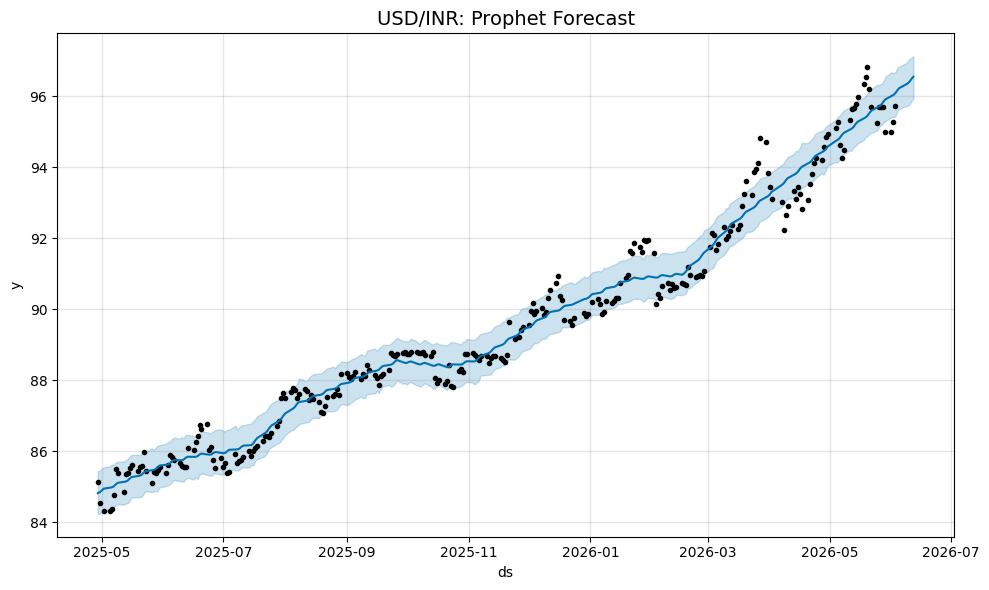

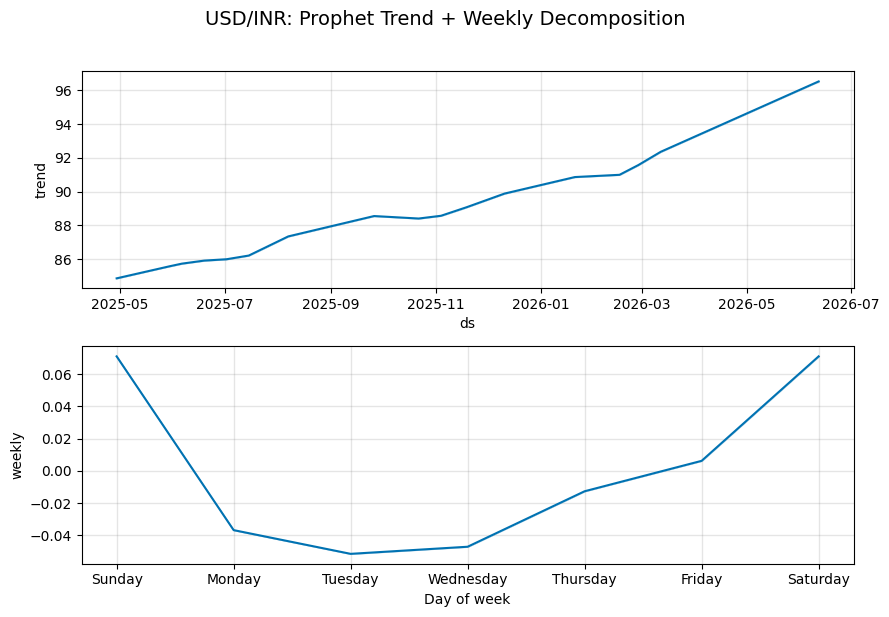


Changepoints detected at:
  2025-05-13
  2025-05-26
  2025-06-06
  2025-06-19
  2025-07-02
  2025-07-15
  2025-07-25
  2025-08-07
  2025-08-20
  2025-09-02
  2025-09-15
  2025-09-26
  2025-10-09
  2025-10-22
  2025-11-04
  2025-11-17
  2025-11-28
  2025-12-11
  2025-12-23
  2026-01-08
  2026-01-21
  2026-02-03
  2026-02-16
  2026-02-27
  2026-03-12

These are dates where Prophet detected the trend shifted.
Useful for your narrative: 'INR depreciation accelerated on [date]'


In [4]:
series = df['usd_inr'].dropna()
model = fit_prophet(series, variant='basic')

future = model.make_future_dataframe(periods=7, freq='B')
forecast = model.predict(future)

# Prophet's built-in plot
fig1 = model.plot(forecast)
plt.title('USD/INR: Prophet Forecast', fontsize=14)
plt.tight_layout()
plt.savefig('prophet_forecast_usdinr.png', dpi=150, bbox_inches='tight')
plt.show()

# Component decomposition — Prophet's unique strength
fig2 = model.plot_components(forecast)
plt.suptitle('USD/INR: Prophet Trend + Weekly Decomposition', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('prophet_components_usdinr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChangepoints detected at:")
for cp in model.changepoints:
    print(f"  {cp.strftime('%Y-%m-%d')}")

print(f"\nThese are dates where Prophet detected the trend shifted.")
print(f"Useful for your narrative: 'INR depreciation accelerated on [date]'")

In [ ]:
import warnings
warnings.filterwarnings('ignore')  # Prophet is verbose

def walk_forward_prophet(series, events_df=None, variant='basic', 
                         forecast_horizon=1, test_days=60):
    """Walk-forward evaluation for Prophet."""
    series = series.dropna()
    
    if len(series) < test_days + 90:
        return None
    
    results = []
    
    # Prepare holidays dataframe based on variant
    holidays_df = None
    if variant in ['events', 'full'] and events_df is not None:
        if variant == 'events':
            holidays_df = events_df[events_df['holiday'].str.contains(
                'Policy|FOMC|RBI|Banxico|BSP')].copy()
        else:
            holidays_df = events_df.copy()
        
        if len(holidays_df) == 0:
            holidays_df = None
    
    for i in range(test_days, 0, -1):
        train = series[:-i]
        actual_value = series.iloc[-i]
        naive_value = train.iloc[-1]
        
        prophet_df = pd.DataFrame({
            'ds': train.index,
            'y': train.values
        })
        
        # Pass holidays in constructor, not via add_holidays
        model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=False,
            changepoint_prior_scale=0.05,
            interval_width=0.80,
            holidays=holidays_df
        )
        
        model.fit(prophet_df)
        
        future = model.make_future_dataframe(periods=forecast_horizon, freq='B')
        forecast = model.predict(future)
        
        last_row = forecast.iloc[-1]
        forecast_value = last_row['yhat']
        forecast_lower = last_row['yhat_lower']
        forecast_upper = last_row['yhat_upper']
        
        actual_direction = 1 if actual_value > train.iloc[-1] else 0
        forecast_direction = 1 if forecast_value > train.iloc[-1] else 0
        
        results.append({
            'date': series.index[-i],
            'actual': actual_value,
            'naive': naive_value,
            'forecast': forecast_value,
            'forecast_lower': forecast_lower,
            'forecast_upper': forecast_upper,
            'naive_error': abs(actual_value - naive_value),
            'forecast_error': abs(actual_value - forecast_value),
            'actual_direction': actual_direction,
            'forecast_direction': forecast_direction
        })
    
    return pd.DataFrame(results)

# Run evaluation for all pairs and all variants
# This takes 15-30 minutes — Prophet refits for every test day

print("Running walk-forward evaluation...")
print("This takes 15-30 min (Prophet refits 60 times per pair per variant)\n")

prophet_evaluation = {}

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    events = events_by_pair.get(col)
    prophet_evaluation[col] = {}
    
    for variant in ['basic', 'events', 'full']:
        print(f"  {col.upper()} — {variant}...", end=" ", flush=True)
        result = walk_forward_prophet(
            df[col], events_df=events, variant=variant,
            forecast_horizon=1, test_days=60
        )
        if result is not None:
            prophet_evaluation[col][variant] = result
            acc = (result['actual_direction'] == result['forecast_direction']).mean() * 100
            print(f"done — direction: {acc:.1f}%")
        else:
            print("skipped")

print("\nAll evaluations complete")

Running walk-forward evaluation...
This takes 15-30 min (Prophet refits 60 times per pair per variant)

  USD_INR — basic... 

01:05:17 - cmdstanpy - INFO - Chain [1] start processing
01:05:18 - cmdstanpy - INFO - Chain [1] done processing
01:05:18 - cmdstanpy - INFO - Chain [1] start processing
01:05:18 - cmdstanpy - INFO - Chain [1] done processing
01:05:18 - cmdstanpy - INFO - Chain [1] start processing
01:05:18 - cmdstanpy - INFO - Chain [1] done processing
01:05:19 - cmdstanpy - INFO - Chain [1] start processing
01:05:19 - cmdstanpy - INFO - Chain [1] done processing
01:05:19 - cmdstanpy - INFO - Chain [1] start processing
01:05:19 - cmdstanpy - INFO - Chain [1] done processing
01:05:20 - cmdstanpy - INFO - Chain [1] start processing
01:05:20 - cmdstanpy - INFO - Chain [1] done processing
01:05:20 - cmdstanpy - INFO - Chain [1] start processing
01:05:20 - cmdstanpy - INFO - Chain [1] done processing
01:05:20 - cmdstanpy - INFO - Chain [1] start processing
01:05:20 - cmdstanpy - INFO - Chain [1] done processing
01:05:21 - cmdstanpy - INFO - Chain [1] start processing
01:05:21 - cmdstanpy - INFO - Chain [1]

done — direction: 41.7%
  USD_INR — events... 

AttributeError: 'Prophet' object has no attribute 'add_holidays'

In [ ]:
print("=== Prophet Variants vs Chronos-Bolt vs Naive Baseline ===\n")

all_rows = []

for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    # Baseline
    for variant_name, result in prophet_evaluation[col].items():
        naive_mae = result['naive_error'].mean()
        model_mae = result['forecast_error'].mean()
        theil_u = model_mae / naive_mae
        direction_acc = (result['actual_direction'] == result['forecast_direction']).mean() * 100
        
        # Interval calibration
        in_interval = ((result['actual'] >= result['forecast_lower']) & 
                       (result['actual'] <= result['forecast_upper'])).mean() * 100
        
        all_rows.append({
            'pair': col.upper(),
            'model': f'Prophet-{variant_name}',
            'theil_u': theil_u,
            'direction_acc': direction_acc,
            'interval_coverage': in_interval
        })
    
    # Add Chronos results for comparison
    if col in chronos_results:
        all_rows.append({
            'pair': col.upper(),
            'model': 'Chronos-Bolt',
            'theil_u': chronos_results[col]['theil_u'],
            'direction_acc': chronos_results[col]['direction_accuracy'] * 100,
            'interval_coverage': chronos_results[col].get('interval_coverage_80', 0) * 100
        })

comparison = pd.DataFrame(all_rows)

# Print per pair
for pair in ['USD_INR', 'USD_EUR', 'USD_GBP', 'USD_MXN', 'USD_PHP']:
    print(f"\n{pair}:")
    subset = comparison[comparison['pair'] == pair]
    print(subset[['model', 'theil_u', 'direction_acc', 'interval_coverage']].to_string(index=False))

In [ ]:
print("=== Did Adding Events Improve Prophet? ===\n")
print("Comparing basic (no events) vs events (policy meetings) vs full (meetings + holidays)\n")

for col in ['usd_inr', 'usd_mxn', 'usd_php']:
    print(f"{col.upper()}:")
    
    basic = prophet_evaluation[col]['basic']
    events = prophet_evaluation[col]['events']
    full = prophet_evaluation[col]['full']
    
    basic_acc = (basic['actual_direction'] == basic['forecast_direction']).mean() * 100
    events_acc = (events['actual_direction'] == events['forecast_direction']).mean() * 100
    full_acc = (full['actual_direction'] == full['forecast_direction']).mean() * 100
    
    basic_theil = basic['forecast_error'].mean() / basic['naive_error'].mean()
    events_theil = events['forecast_error'].mean() / events['naive_error'].mean()
    full_theil = full['forecast_error'].mean() / full['naive_error'].mean()
    
    print(f"  Basic:   Theil U = {basic_theil:.4f}   Direction = {basic_acc:.1f}%")
    print(f"  Events:  Theil U = {events_theil:.4f}   Direction = {events_acc:.1f}%")
    print(f"  Full:    Theil U = {full_theil:.4f}   Direction = {full_acc:.1f}%")
    
    # Did events help?
    if events_acc > basic_acc + 2:
        print(f"  → Policy meetings improved direction accuracy by {events_acc - basic_acc:.1f}pp")
    elif events_acc < basic_acc - 2:
        print(f"  → Policy meetings actually HURT by {basic_acc - events_acc:.1f}pp")
    else:
        print(f"  → Policy meetings made no meaningful difference")
    
    # Did holidays help beyond events?
    if full_acc > events_acc + 2:
        print(f"  → Holidays added {full_acc - events_acc:.1f}pp beyond policy meetings")
        print(f"  → SUPPORTS retail remittance hypothesis")
    elif full_acc < events_acc - 2:
        print(f"  → Holidays actually HURT by {events_acc - full_acc:.1f}pp")
        print(f"  → REJECTS retail remittance hypothesis")
    else:
        print(f"  → Holidays made no meaningful difference")
        print(f"  → INCONCLUSIVE on retail remittance hypothesis")
    print()

print("Note: with only 60 test days and few holiday events in the test period,")
print("these results are suggestive, not definitive. Would need 2+ years of data")
print("to properly test the holiday hypothesis.")

In [ ]:
print("=== Changepoint Detection Across All Pairs ===\n")
print("Prophet automatically detects where the trend shifted.\n")

fig, axes = plt.subplots(5, 1, figsize=(16, 25))

for i, col in enumerate(['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']):
    series = df[col].dropna()
    prophet_df = pd.DataFrame({'ds': series.index, 'y': series.values})
    
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model.fit(prophet_df)
    
    future = model.make_future_dataframe(periods=0, freq='B')
    forecast = model.predict(future)
    
    # Plot
    axes[i].plot(series.index, series.values, color='black', linewidth=1, label='Rate')
    axes[i].plot(forecast['ds'], forecast['trend'], color='blue', linewidth=1.5, label='Prophet trend')
    
    # Mark changepoints
    for cp in model.changepoints:
        axes[i].axvline(cp, color='red', linestyle='--', alpha=0.4)
    
    axes[i].set_title(f'{col.upper()} — {len(model.changepoints)} changepoints detected', fontsize=13)
    axes[i].legend(loc='best')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Prophet Changepoint Detection Across Currency Pairs', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('prophet_changepoints_all.png', dpi=150, bbox_inches='tight')
plt.show()

# Print changepoint dates for narrative use
print("\nChangepoint dates (for narrative layer):\n")
for col in ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']:
    series = df[col].dropna()
    prophet_df = pd.DataFrame({'ds': series.index, 'y': series.values})
    
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model.fit(prophet_df)
    
    print(f"{col.upper()}: {len(model.changepoints)} changepoints")
    for cp in model.changepoints:
        print(f"  {cp.strftime('%Y-%m-%d')}")
    print()

In [ ]:
prophet_output = {}

for col in prophet_evaluation:
    prophet_output[col] = {}
    for variant, result in prophet_evaluation[col].items():
        naive_mae = result['naive_error'].mean()
        model_mae = result['forecast_error'].mean()
        
        in_interval = ((result['actual'] >= result['forecast_lower']) & 
                       (result['actual'] <= result['forecast_upper'])).mean()
        
        prophet_output[col][variant] = {
            'model': f'prophet-{variant}',
            'test_days': len(result),
            'naive_mae': float(naive_mae),
            'prophet_mae': float(model_mae),
            'theil_u': float(model_mae / naive_mae),
            'direction_accuracy': float((result['actual_direction'] == result['forecast_direction']).mean()),
            'interval_coverage_80': float(in_interval)
        }

with open('prophet_results.json', 'w') as f:
    json.dump(prophet_output, f, indent=2)

print("Prophet results saved to prophet_results.json")
print("\nNext: notebook 05 — GARCH volatility forecasting")